# Atividade 3 -- Tópicos para Computação 1 -- 2026.1

- Escola Superior de Tecnologia
- Profa. Dra. Elloá B. Guedes (ebgcosta@uea.edu.br)
- www.elloaguedes.com
- github.com/elloa
- Data: 19 de março de 2026

## Descrição

A atividade consiste em construir uma rede neural convolucional para classificar o _Stanford Dogs Dataset_, um dataset com imagens de 120 raças de cachorro de todo o mundo e mais de 20 mil imagens para treino e teste.

## Material de Referência para Estudo

- http://vision.stanford.edu/aditya86/ImageNetDogs/


## Prazos importantes

- Data de entrega: 23/03/2026
- Modo de entrega: Google Classroom
- Estratégia de desenvolvimento: Quartetos (a interseção com grupos anteriores deve ter tamanho máximo igual a 2)

# Obtenção do dataset

- A tarefa a ser considerada é uma tarefa de classificação multiclasse
- A documentação oficial do dataset pode ser obtida aqui: http://vision.stanford.edu/aditya86/ImageNetDogs/
- Vamos usar essa versão do Kaggle em que as imagens e rótulos já estão organizados:
  https://www.kaggle.com/datasets/miljan/stanford-dogs-dataset-traintest
- Instale a API do Kaggle e faça o download do dataset usando Python
- Organize o nome das classes, retire o identificador "n[id]" do início das pastas

In [4]:
import os 
import csv
from tqdm import tqdm
import kagglehub
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR

In [5]:
# Download Dataset
path = kagglehub.dataset_download("miljan/stanford-dogs-dataset-traintest")

print("Path to dataset files:", path)

100%|██████████| 393M/393M [00:11<00:00, 37.1MB/s] 

Extracting files...


Path to dataset files: /home/gui/.cache/kagglehub/datasets/miljan/stanford-dogs-dataset-traintest/versions/1


In [6]:
def rename_classes(path):

    for name in os.listdir(path):

        old_path = os.path.join(path, name)

        if os.path.isdir(old_path):

            new_name = name.split("-",1)[1]

            new_path = os.path.join(path, new_name)

            os.rename(old_path, new_path)


rename_classes(os.path.join(path,"cropped/train"))
rename_classes(os.path.join(path,"cropped/test"))

# Transformações na Entrada, Image Handler e Data Loader

- As imagens precisam ser padronizadas, vamos usar as dimensões 224x224 e a normalização das cores
- Transformação das Imagens: https://docs.pytorch.org/vision/0.8/transforms.html
- Operações: Redimensionamento, Para Tensor e Normalização ([-1,1] com média 0.5 e desvio padrão de 0.5)
- Criar um ImageHandler para cada pasta (treino/teste):
  - https://docs.pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html#torchvision.datasets.ImageFolder
- Para o treinamento: criar um Data loader com tamanho de lote igual a 32 e randomização
- https://docs.pytorch.org/docs/stable/data.html
- Para o teste: criar um Data loader com lote de tamanho igual a 1 e sem randomização

In [7]:
# transform = transforms.Compose([
#     transforms.Resize((224,224)),
#     transforms.ToTensor(),
#     transforms.Normalize(
#         mean=[0.5,0.5,0.5],
#         std=[0.5,0.5,0.5]
#     )
# ])

In [8]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

In [9]:
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

In [10]:
train_dataset = ImageFolder(
    root=os.path.join(path,"cropped/train"),
    transform=train_transform
)

test_dataset = ImageFolder(
    root=os.path.join(path,"cropped/test"),
    transform=test_transform
)

In [11]:
print("Número de classes:", len(train_dataset.classes))
print(train_dataset.classes[:10])

Número de classes: 120
['Afghan_hound', 'African_hunting_dog', 'Airedale', 'American_Staffordshire_terrier', 'Appenzeller', 'Australian_terrier', 'Bedlington_terrier', 'Bernese_mountain_dog', 'Blenheim_spaniel', 'Border_collie']


In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)

In [13]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


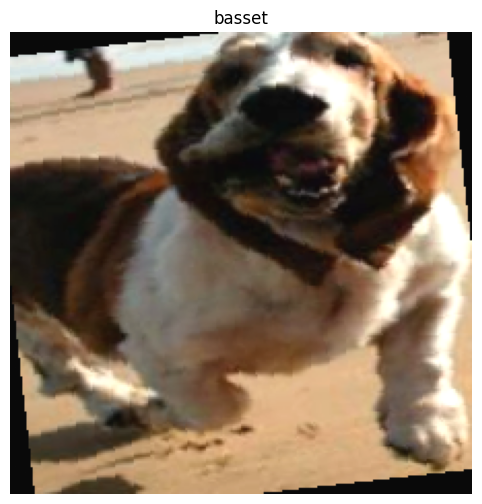

In [14]:
import matplotlib.pyplot as plt

img = images[0]

# desfazer normalização
img = img * 0.5 + 0.5

plt.figure(figsize=(8,6))
plt.imshow(img.permute(1,2,0))
plt.title(train_dataset.classes[labels[0]])
plt.axis("off")
plt.show()

## Entendendo o Image Handler (dataset.ImageFolder) DataLoader

- Responda ao que se pede:
    1. Qual o papel do ImageHandler nesse contexto?
    2. E do DataLoader?
    3. Por que o tamanho do batch não pode ser todo o conjunto de dados?
    4. Por que o DataLoader do treinamento precisa de aleatoriedade?
    5. Por que o DataLoader do teste deve ter batch igual a 1 e sem aleatoriedade?

1. O ImageFolder atua como a representação do seu conjunto de dados (o Dataset). O papel dele é mapear e ler a estrutura de diretórios onde suas imagens estão guardadas. Ele descobre automaticamente quais são as classes baseando-se no nome das pastas e sabe como carregar e aplicar transformações a uma imagem individual quando solicitado.

2. O DataLoader envolve o Dataset (ImageFolder) e é responsável por pegar aqueles itens individuais e agrupá-los em lotes (batches). Além disso, o DataLoader gerencia como esses lotes são entregues ao modelo, cuidando da paralelização (usando múltiplos núcleos do processador para carregar imagens mais rápido) e da ordem de entrega dos dados.

3. Carregar milhares ou milhões de imagens simultaneamente esgotaria rapidamente a memória RAM do computador ou a memória de vídeo (VRAM) da placa de vídeo (GPU), e treinar usando lotes menores (Mini-batch Gradient Descent) permite que a rede neural atualize os pesos várias vezes durante uma única época. Isso introduz um leve ruído benéfico que ajuda o modelo a convergir mais rápido e evita que ele fique preso em soluções sub-ideais (mínimos locais).

4. A aleatoriedade é essencial para que o modelo não decore a ordem em que as imagens aparecem. Se o modelo sempre recebesse primeiro todas as fotos de gatos e depois todas as fotos de cachorros, ele esqueceria os gatos enquanto aprende sobre os cachorros, causando oscilações e um aprendizado ruim. Misturar os dados garante que cada lote contenha amostras variadas.

5. Durante o teste, o modelo não é mais treinado, apenas avaliado. A ordem original dos dados serve para conseguir comparar facilmente a previsão que o modelo fez com o rótulo verdadeiro exato daquela imagem. E embora na prática o batch de teste possa ser maior para acelerar o processo (já que não gastamos memória guardando gradientes), usar um batch de 1 é muito comum para a depuração. Isso permite inspecionar o resultado do modelo individualmente, imagem por imagem, facilitando a análise visual de onde a rede está errando ou acertando.

## Construindo sua primeira CNN: AlexNet

- Construa, camada a camada, a CNN AlexNet, vencedora do ImageNet 2012
- Arquitetura da AlexNet é dada a seguir:
1. Conv 1: 96 filtros de tamanho $11 \times 11$, com um stride (passo) de 4.
2. Max Pool 1: Redução espacial com janelas de $3 \times 3$ e stride 2.
3. Conv 2: 256 filtros de $5 \times 5$ com padding para manter a dimensão.
4. Max Pool 2: Outra redução de $3 \times 3$ com stride 2.
5. Conv 3, 4 e 5: Camadas convolucionais puras (sem pooling entre elas) com 384, 384 e 256 filtros de $3 \times 3$, respectivamente.
6. Max Pool 3: Última redução antes das camadas densas.
7. Camada de adaptação para classificação: Adaptive Average Pooling Bidimensional 6x6
8. FC 6 e 7: Duas camadas densas com 4096 neurônios cada, utilizando Dropout de 0.5 para reduzir o overfitting.
9. FC 8 (Saída): Camada final com ativação Softmax. Ajuste a camada de saída para o número de classes do problema encontrado.

### Sumário do Modelo

- Apresente o sumário do modelo, indicando quantos parâmetros ele possui e quantos destes são treináveis.


### Links Úteis

- https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.pooling.MaxPool2d.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.activation.ReLU.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.pooling.AdaptiveAvgPool2d.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.dropout.Dropout.html





In [15]:
class AlexNet(nn.Module):

    def __init__(self, num_classes=120):
        super(AlexNet, self).__init__()

        # Camadas convolucionais
        self.features = nn.Sequential(

            # Conv1
            nn.Conv2d(3, 96, kernel_size=11, stride=4),
            nn.ReLU(inplace=True),

            # MaxPool1
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv2
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),

            # MaxPool2
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv3
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv4
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv5
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # MaxPool3
            nn.MaxPool2d(kernel_size=3, stride=2)
        )

        # Adaptative pooling
        self.avgpool = nn.AdaptiveAvgPool2d((6,6))

        # Camada totalmente conectada
        self.classifier = nn.Sequential(

            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),

            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),

            nn.Linear(4096, num_classes)
        )

        self._initialize_weights()

    def forward(self, x):

        x = self.features(x)
        x = self.avgpool(x)

        x = torch.flatten(x, 1)

        x = self.classifier(x)

        return x
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

## Configuração do Treino

- 120 épocas
- Otimizador: Mini-batch SGD com Momentum (tal qual no paper original da AlexNet)
- Zere os gradientes do otimizador
- Lotes de 32
- Taxa de aprendizado: 10^(-3)
- Momentum: 0.9
- Função de perda: Entropia Cruzada Categórica
- Caso tenha disponibilidade, acelere o treino com GPU

### Monitorando o Treinamento

- Ao longo das épocas, armazene o loss e a acurácia no treino em um arquivo csv

#### Links Úteis

- https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
- https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html

In [16]:
EPOCHS = 120
LEARNING_RATE = 1e-4
MOMENTUM = 0.9

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


print("Device:", device)

Device: cuda


In [18]:
model = AlexNet(num_classes=120).to(device)

criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LEARNING_RATE,
    momentum=MOMENTUM
)

In [19]:
scheduler = StepLR(optimizer=optimizer, step_size=30, gamma=0.5)

In [20]:
with open("training_log.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch","loss","accuracy"])

In [21]:
epochs = EPOCHS

for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for batch_idx, (images, labels) in enumerate(pbar):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        acc = correct / total

        # atualizar barra com métricas instantâneas
        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{acc:.4f}",
            "batch": f"{batch_idx+1}/{len(train_loader)}"
        })

    scheduler.step()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    print(f"Epoch {epoch+1}/{epochs}  Loss:{epoch_loss:.4f}  Acc:{epoch_acc:.4f}")

    # salvar no csv
    with open("training_log.csv","a",newline="") as f:
        writer = csv.writer(f)
        writer.writerow([epoch+1, epoch_loss, epoch_acc])

Epoch 1/120: 100%|██████████| 375/375 [00:48<00:00,  7.68it/s, loss=4.7777, acc=0.0084, batch=375/375]


Epoch 1/120  Loss:4.7893  Acc:0.0084


Epoch 2/120: 100%|██████████| 375/375 [00:46<00:00,  8.05it/s, loss=4.7764, acc=0.0079, batch=375/375]


Epoch 2/120  Loss:4.7879  Acc:0.0079


Epoch 3/120: 100%|██████████| 375/375 [00:52<00:00,  7.09it/s, loss=4.7871, acc=0.0095, batch=375/375]


...

Epoch 69/120  Loss:4.1866  Acc:0.0533


Epoch 70/120: 100%|██████████| 375/375 [00:48<00:00,  7.75it/s, loss=4.4114, acc=0.0552, batch=375/375]


Epoch 70/120  Loss:4.1826  Acc:0.0552


Epoch 71/120:  65%|██████▌   | 245/375 [00:37<00:19,  6.50it/s, loss=4.2485, acc=0.0541, batch=245/375]


KeyboardInterrupt: 

## Métricas do Treinamento

- Elabore um gráfico com a função de perda ao longo das épocas
- Elabore um gráfico com a acurácia do conjunto de treino ao longo das épocas
- Responda: O treino foi eficiente?

### Persista o modelo

- Salvar o modelo com os pesos após o aprendizado é uma estratégia importante para posteriormente utilizá-lo para inferência ou para análises comparativas
- Nesta atividade, salve o modelo em disco e recupere-o para efetuar a avaliação no conjunto de testes

In [ ]:
# Persistência do Modelo

torch.save(model.state_dict(), "models/alexnet_final.pth")

In [ ]:
import requests

import httpx

httpx.get("http")

InvalidURL: Invalid URL 'https:/eee/drive.google.com/file/d/14OCyZakwt8zJzIvEHXouqsF_Ho6D-NUh/view?usp=drive_link': No host supplied

In [ ]:
with open("modelo.pth", "wb") as f:
    f.write(response.content)

In [ ]:
# Carregamento do Modelo

model = AlexNet()
model.load_state_dict(torch.load("modelo.pth"))
model.eval()

UnpicklingError: Weights only load failed. In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
Please file an issue with the following so that we can make `weights_only=True` compatible with your use case: WeightsUnpickler error: 

Unsupported operand 60

Check the documentation of torch.load to learn more about types accepted by default with weights_only https://pytorch.org/docs/stable/generated/torch.load.html.

In [ ]:
# Carregamento do Modelo

model = AlexNet()
model.load_state_dict(torch.load("models/alexnet_final.pth"))
model.eval()

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
    (2): ReLU(inp

## Avaliação do Modelo

- Faça as inferências do modelo para o conjunto de testes e cálcule as métricas para uma tarefa de classificação multiclasse
- Elabore uma matriz de confusão
- Escolha três exemplos aleatórios do conjunto de testes, exiba-as e mostre também as top-3 probabilidades de classificação

## Parecer Avaliativo

- Elabore um parecer sobre o desempenho do modelo, elencando vantagens e limitações
- Faça a sugestão de três estratégias a serem incorporadas no modelo ou em seu treinamento para que haja melhoria de desempenho